In [112]:
#import libraries

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

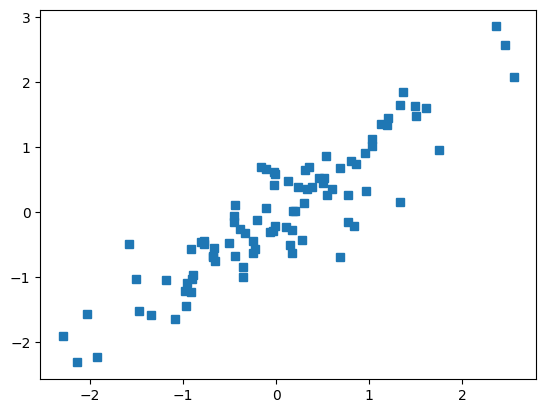

In [113]:
# create data

N = 90
x = torch.randn(N,1)
y = x + torch.randn(N,1)/2

plt.plot(x,y,'s')
plt.show()

In [114]:
#building model

ANN_reg = nn.Sequential(
    nn.Linear(1,1), #input layer
    nn.ReLU(), #activation function
    nn.Linear(1,1) #output layer
)

In [115]:
ANN_reg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [116]:
learning_rate = 0.05

lossfun = nn.MSELoss() #loss function

optimizer = torch.optim.SGD(ANN_reg.parameters(), lr = learning_rate) #optimizer (the flavour of GD to implement)

In [117]:
#train the model

numepochs = 500
losses = torch.zeros(numepochs)

for ep in range(numepochs):

  #forward pass
  y_Hat = ANN_reg(x)

  #compute losses
  loss = lossfun(y_Hat,y)
  losses[ep] = loss
  #backprop
  optimizer.zero_grad() #clears out the gradient info from the previous epoch
  loss.backward() #computes the loss values based ob the loss function
  optimizer.step() #propagtes those errors

In [118]:
losses

tensor([0.6110, 0.5906, 0.5714, 0.5529, 0.5355, 0.5194, 0.5045, 0.4907, 0.4781,
        0.4665, 0.4556, 0.4454, 0.4360, 0.4273, 0.4193, 0.4119, 0.4050, 0.3984,
        0.3922, 0.3865, 0.3811, 0.3761, 0.3714, 0.3669, 0.3627, 0.3587, 0.3551,
        0.3516, 0.3483, 0.3452, 0.3423, 0.3395, 0.3369, 0.3344, 0.3320, 0.3297,
        0.3276, 0.3255, 0.3235, 0.3216, 0.3198, 0.3180, 0.3164, 0.3148, 0.3132,
        0.3116, 0.3101, 0.3087, 0.3075, 0.3063, 0.3051, 0.3040, 0.3029, 0.3018,
        0.3007, 0.2997, 0.2986, 0.2976, 0.2965, 0.2956, 0.2946, 0.2937, 0.2928,
        0.2919, 0.2910, 0.2899, 0.2886, 0.2872, 0.2859, 0.2846, 0.2833, 0.2820,
        0.2808, 0.2796, 0.2783, 0.2771, 0.2759, 0.2747, 0.2736, 0.2725, 0.2714,
        0.2703, 0.2693, 0.2683, 0.2673, 0.2663, 0.2654, 0.2645, 0.2636, 0.2627,
        0.2619, 0.2610, 0.2602, 0.2594, 0.2586, 0.2579, 0.2571, 0.2563, 0.2555,
        0.2548, 0.2539, 0.2531, 0.2523, 0.2515, 0.2507, 0.2499, 0.2492, 0.2485,
        0.2477, 0.2470, 0.2464, 0.2457, 

Text(0.5, 1.0, 'Final Loss : 0.19308730959892273')

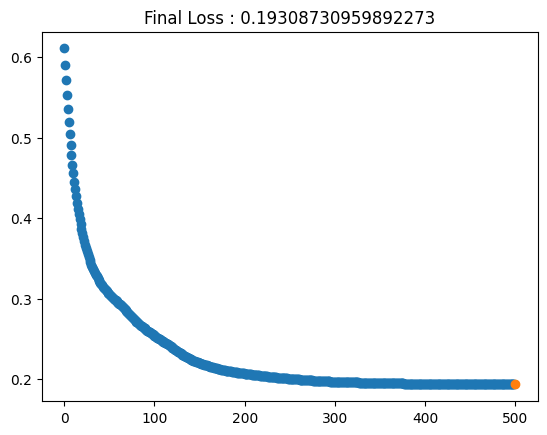

In [119]:
predictions = ANN_reg(x)


testloss = (predictions-y).pow(2).mean()

plt.plot(losses.detach(), 'o')
plt.plot(numepochs, testloss.detach(),'o')
plt.title(f'Final Loss : {testloss.item()}')

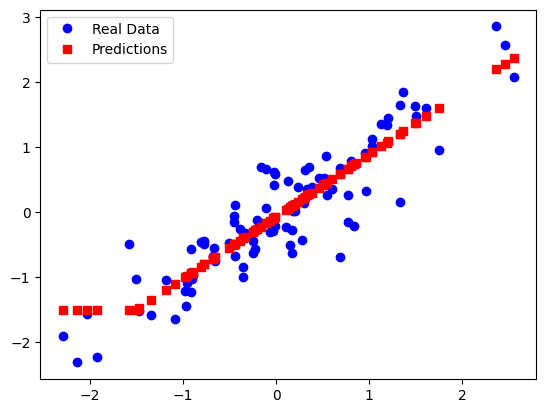

In [120]:
plt.plot(x,y,'bo',label='Real Data')
plt.plot(x, predictions.detach(), 'rs', label='Predictions')
plt.legend()

plt.show()